# EDA (Exploratory Data Analysis)
- Statistical Analysis
- Data Visualization

In [1]:
# Imports
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

import warnings
warnings.filterwarnings("ignore")
print("Imports Loaded Successfully")

Imports Loaded Successfully


In [2]:
# Configuration
DATASET = "cleaned_movie_data.csv"

TARGET = "imdb_binned"

FIGURE_WIDTH = 12
FIGURE_HEIGHT = 6

TOP_N = 10

In [3]:
# Utility Functions
def get_column_types(df):

    numerical = df.select_dtypes(include="number").columns.tolist()

    categorical = df.select_dtypes(include="object").columns.tolist()

    return numerical, categorical


def show_shape(df):

    print(f"Rows : {df.shape[0]}")
    print(f"Columns : {df.shape[1]}")

In [4]:
# Load dataset
def load_dataset(path):
    return pd.read_csv(path)

In [5]:
# Visualization Functions
def plot_bar(series, title, xlabel, ylabel):

    plt.figure(figsize=(FIGURE_WIDTH, FIGURE_HEIGHT))

    ax = series.plot(
        kind="bar"
    )

    for container in ax.containers:
        ax.bar_label(container)

    plt.title(title)

    plt.xlabel(xlabel)

    plt.ylabel(ylabel)

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()

In [6]:
def plot_box(df, column):

    plt.figure(figsize=(10,5))

    sns.boxplot(
        data=df,
        x=TARGET,
        y=column
    )

    plt.title(f"{column} vs {TARGET}")

    plt.show()

In [7]:
def plot_scatter(df, column):

    plt.figure(figsize=(8,5))

    sns.scatterplot(
        data=df,
        x=TARGET,
        y=column
    )

    plt.title(f"{column} vs {TARGET}")

    plt.show()

In [8]:

def plot_categorical(df, column):

    top = df[column].value_counts().head(TOP_N).index

    temp = df[df[column].isin(top)]

    ct = pd.crosstab(
        temp[column],
        temp[TARGET]
    )

    ct.plot(
        kind="bar",
        figsize=(12,5)
    )

    plt.title(f"{column} vs {TARGET}")

    plt.tight_layout()

    plt.show()

In [9]:
# Load Dataset
df = load_dataset(DATASET)
show_shape(df)
df.head()

# Dataset Overview
df.info()
df.describe()
df.describe(include="object")

# Missing value
missing_values = df.isnull().sum()

# Missing percentage
missing_percentage = (
        (missing_values / len(df)) * 100
).round(2)

missing_df = pd.DataFrame({
    "Column": df.columns,
    "Missing Values": missing_values.values,
    "Missing (%)": missing_percentage.values
})

# Display only columns with missing values
missing_df = missing_df[missing_df["Missing Values"] > 0]

if missing_df.empty:
    print("No missing values found in the dataset.")
else:
    print(
        missing_df.sort_values(
            by="Missing Values",
            ascending=False
        )
    )


Rows : 4998
Columns : 35
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4998 entries, 0 to 4997
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   color                      4998 non-null   object 
 1   director_name              4998 non-null   object 
 2   num_critic_for_reviews     4998 non-null   float64
 3   duration                   4998 non-null   float64
 4   director_facebook_likes    4998 non-null   float64
 5   actor_3_facebook_likes     4998 non-null   float64
 6   actor_2_name               4998 non-null   object 
 7   actor_1_facebook_likes     4998 non-null   float64
 8   gross                      4998 non-null   float64
 9   genres                     4998 non-null   object 
 10  actor_1_name               4998 non-null   object 
 11  num_voted_users            4998 non-null   float64
 12  cast_total_facebook_likes  4998 non-null   float64
 13  actor_3_name           

In [10]:
# Count duplicate rows
duplicate_count = df.duplicated().sum()

duplicate_percentage = (
                               duplicate_count / len(df)
                       ) * 100

print(f"Total Records          : {len(df)}")
print(f"Duplicate Records      : {duplicate_count}")
print(f"Duplicate Percentage   : {duplicate_percentage:.2f}%")

Total Records          : 4998
Duplicate Records      : 0
Duplicate Percentage   : 0.00%


imdb_binned
HIT     3428
AVG     1524
FLOP      46
Name: count, dtype: int64


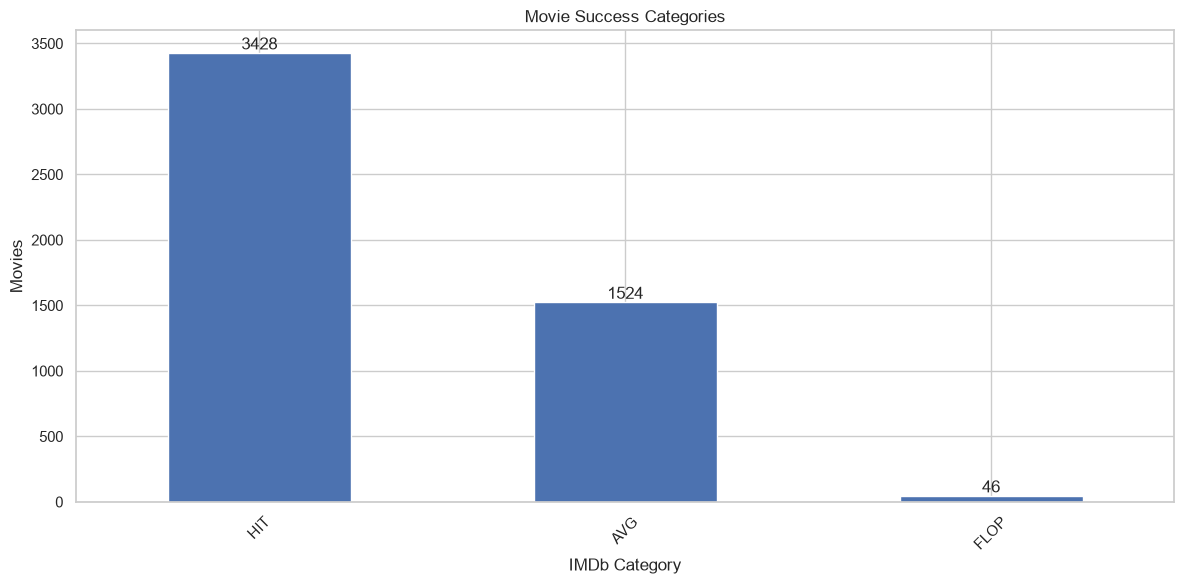

In [11]:
# Target Distribution
target_distribution = df[TARGET].value_counts()
print(target_distribution)
plot_bar(
    target_distribution,
    "Movie Success Categories",
    "IMDb Category",
    "Movies"
)

In [12]:
# Column Types
num_cols, cat_cols = get_column_types(df)
print(num_cols)
print(cat_cols)

['num_critic_for_reviews', 'duration', 'director_facebook_likes', 'actor_3_facebook_likes', 'actor_1_facebook_likes', 'gross', 'num_voted_users', 'cast_total_facebook_likes', 'facenumber_in_poster', 'num_user_for_reviews', 'budget', 'title_year', 'actor_2_facebook_likes', 'aspect_ratio', 'movie_facebook_likes', 'is_color', 'log_budget', 'log_gross', 'roi', 'review_ratio', 'votes_per_review', 'actor_lead_share', 'director_share', 'movie_age']
['color', 'director_name', 'actor_2_name', 'genres', 'actor_1_name', 'actor_3_name', 'plot_keywords', 'language', 'country', 'content_rating', 'imdb_binned']


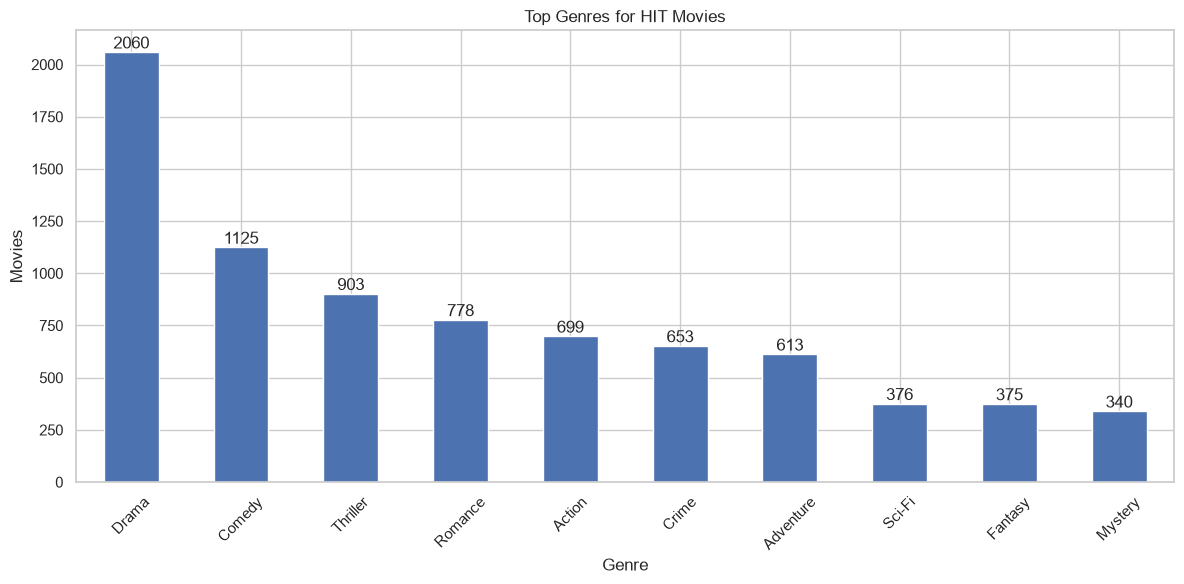

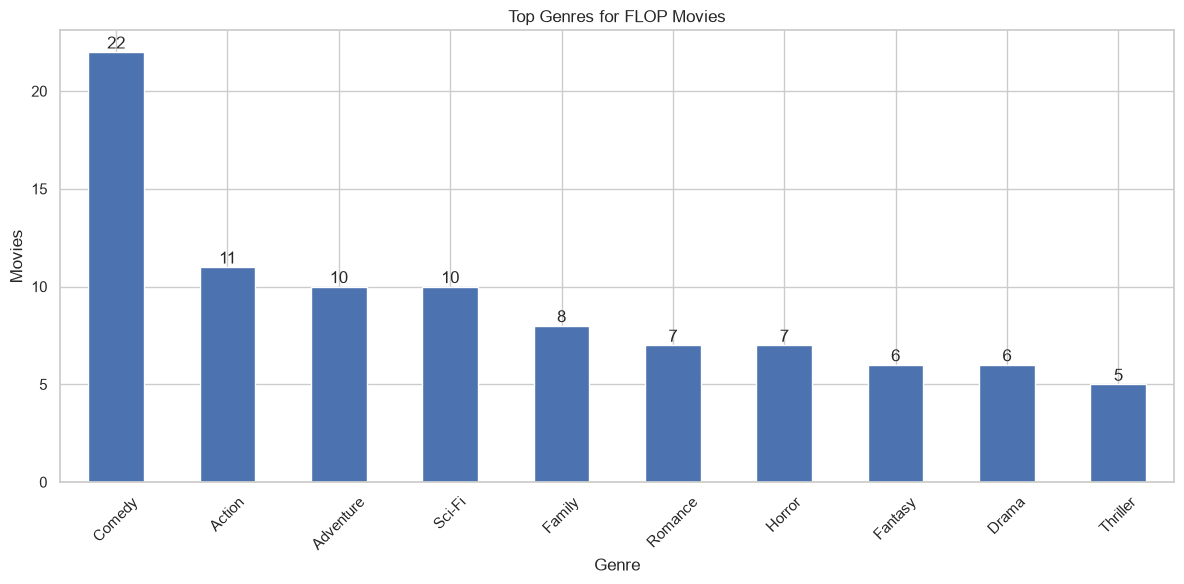

In [13]:
# Genre Analysis
genre_df = df.copy()

genre_df["genres"] = genre_df["genres"].str.split("|")

genre_df = genre_df.explode("genres")

hit = ( genre_df[genre_df[TARGET] == "HIT"]

    .groupby("genres")

    .size()

    .sort_values(ascending=False)

    .head(TOP_N)
)
plot_bar(
    hit,
    "Top Genres for HIT Movies",
    "Genre",
    "Movies"
)
flop = (genre_df[genre_df[TARGET] == "FLOP"]

    .groupby("genres")

    .size()

    .sort_values(ascending=False)

    .head(TOP_N)
)

plot_bar(
    flop,
    "Top Genres for FLOP Movies",
    "Genre",
    "Movies"
)

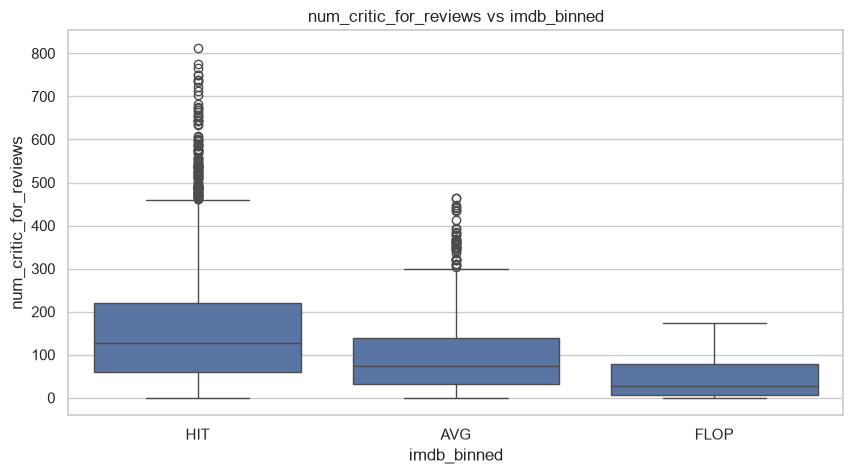

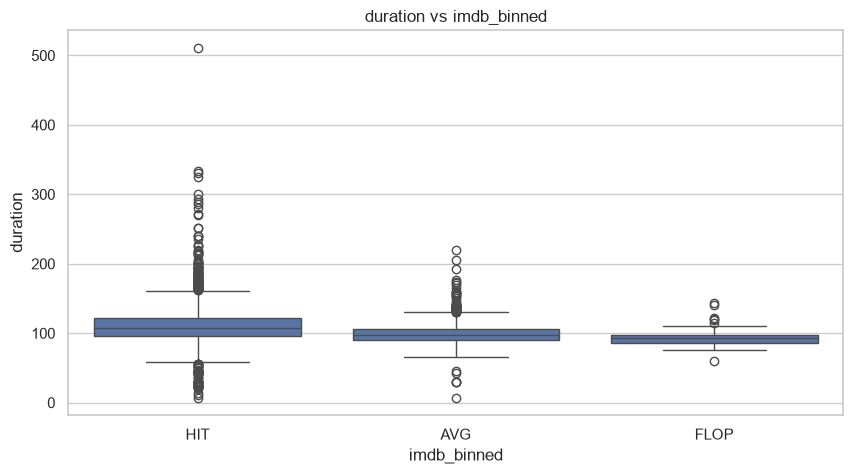

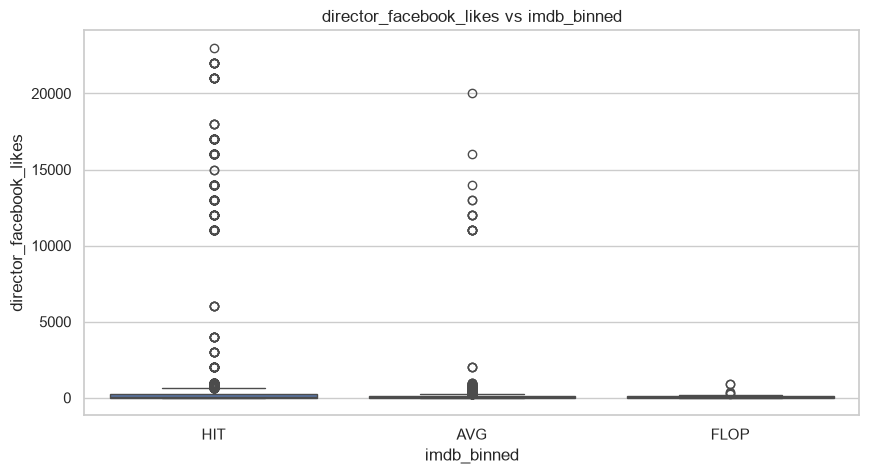

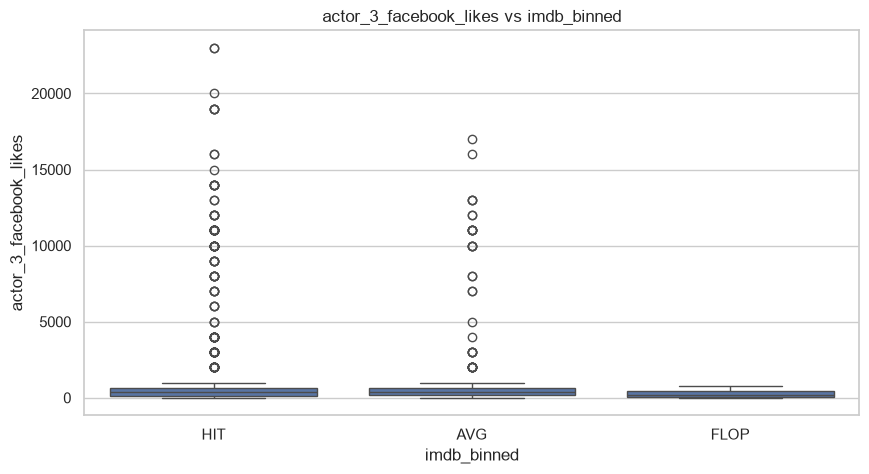

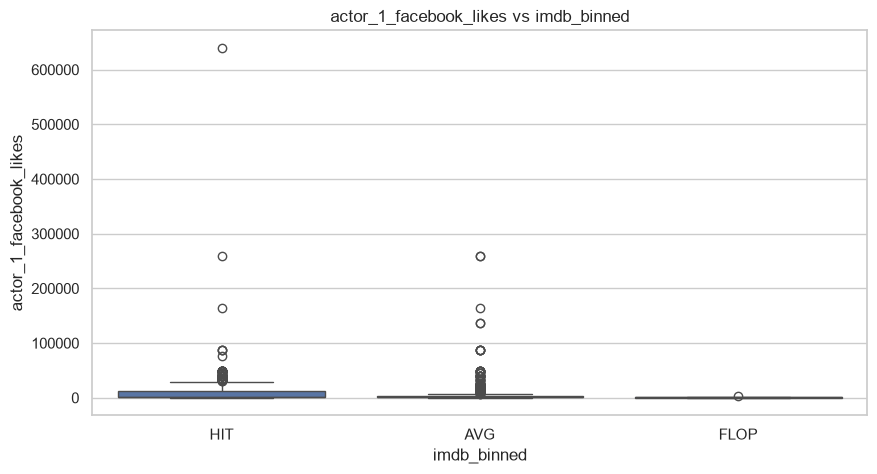

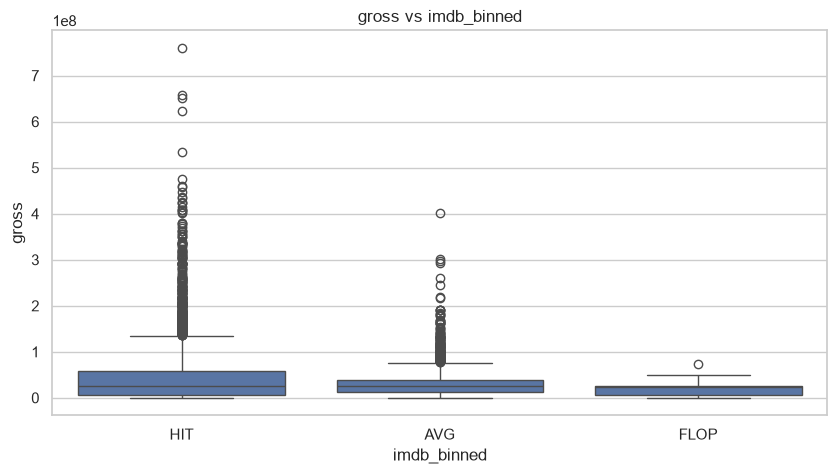

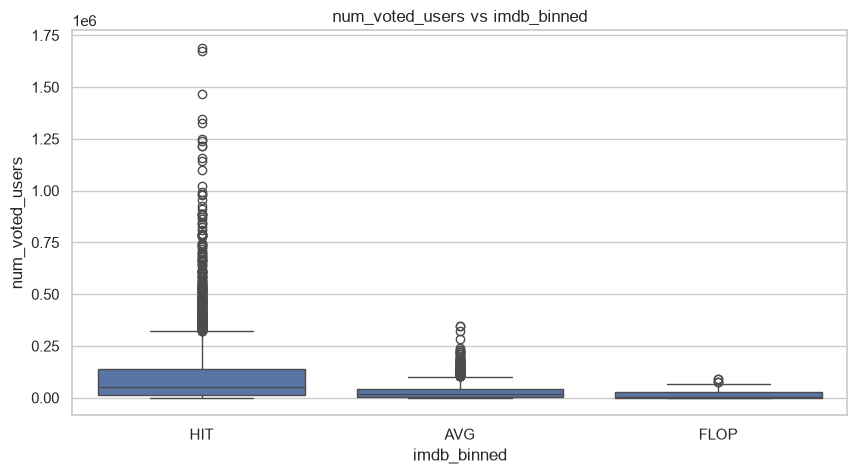

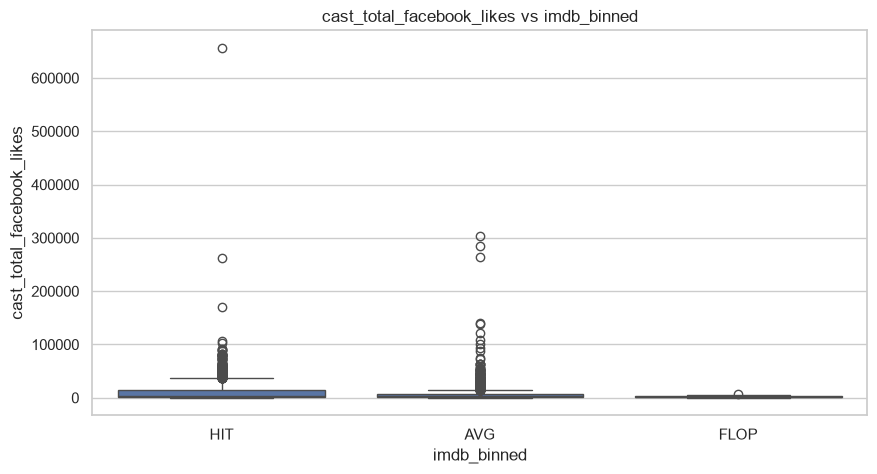

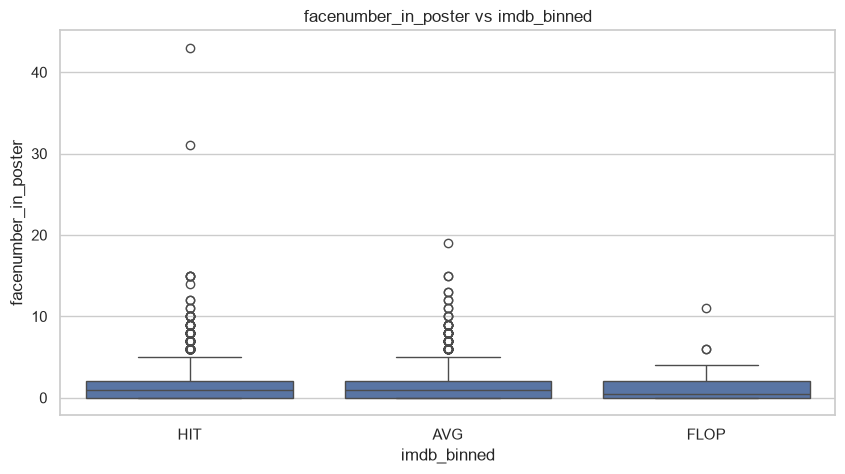

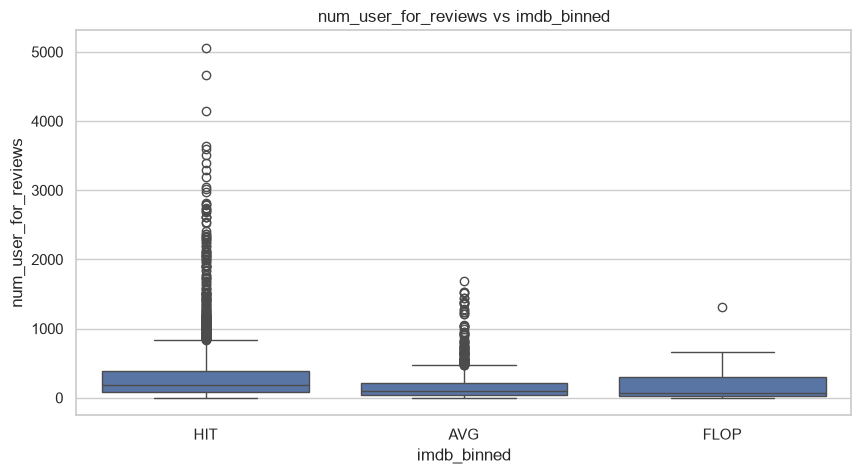

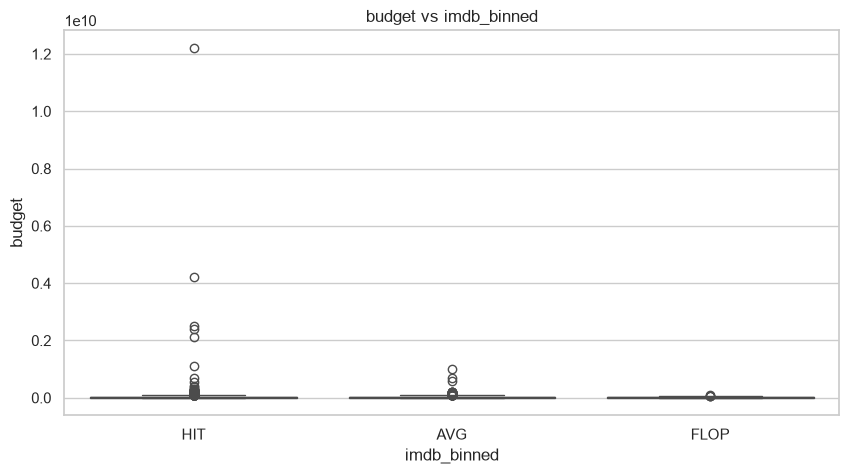

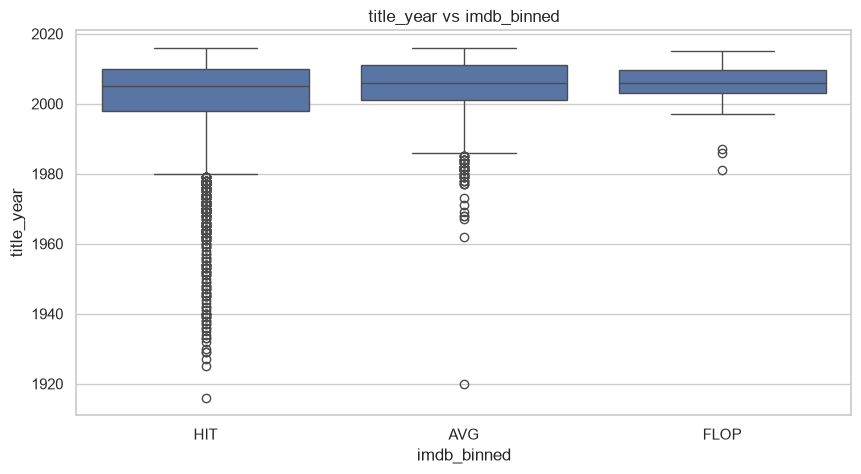

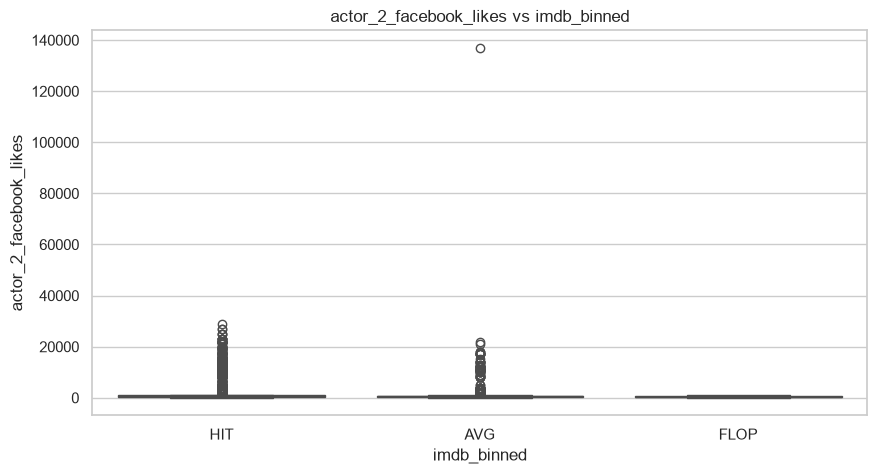

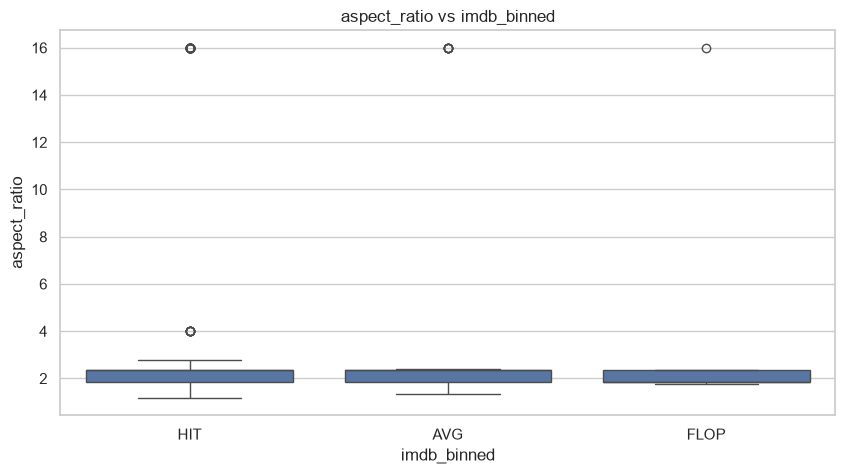

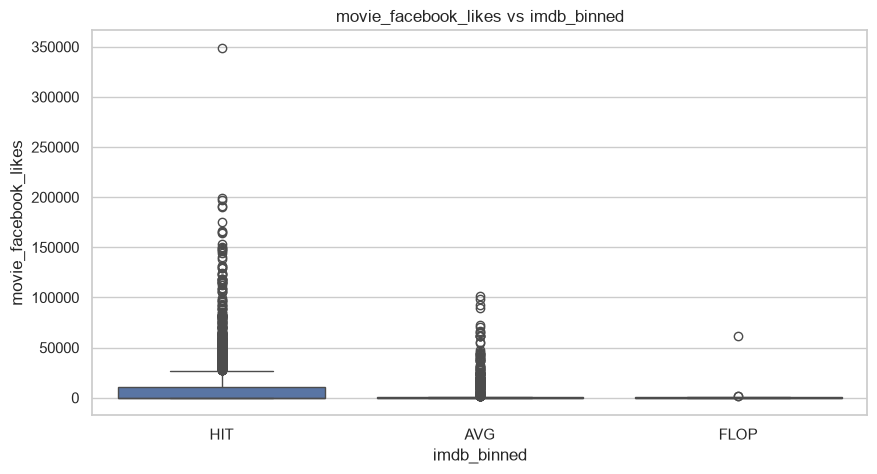

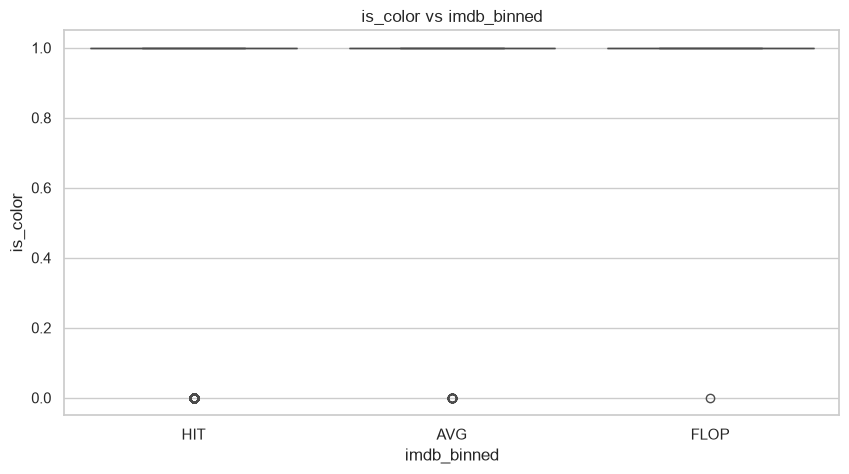

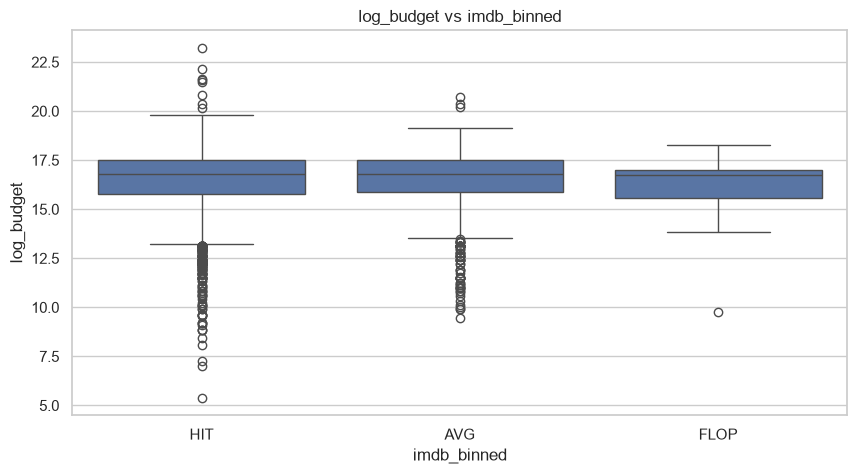

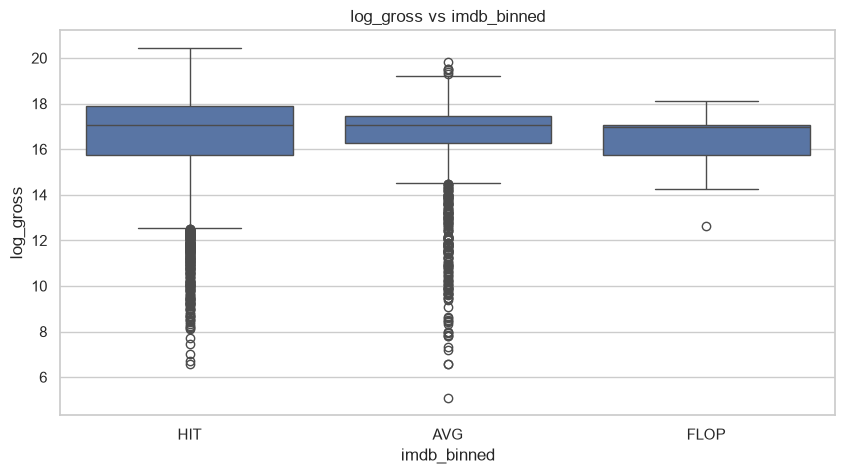

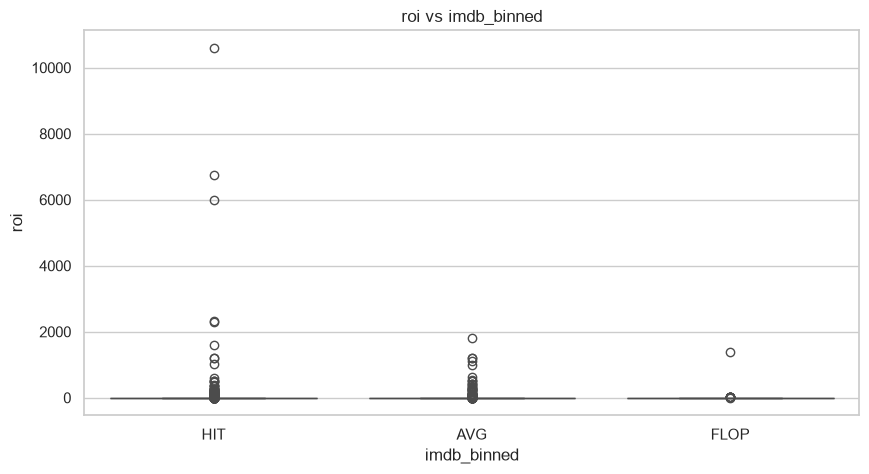

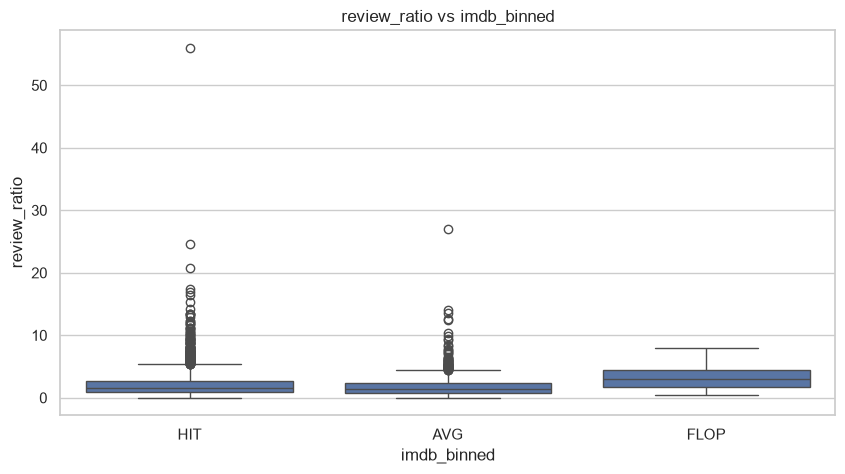

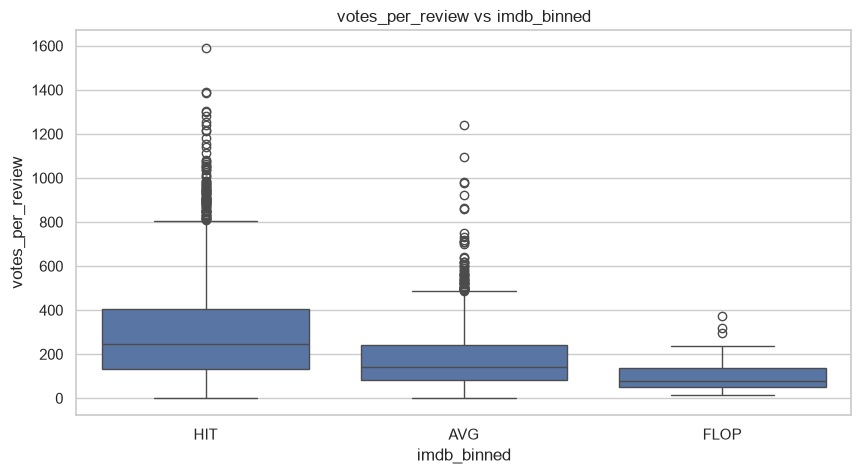

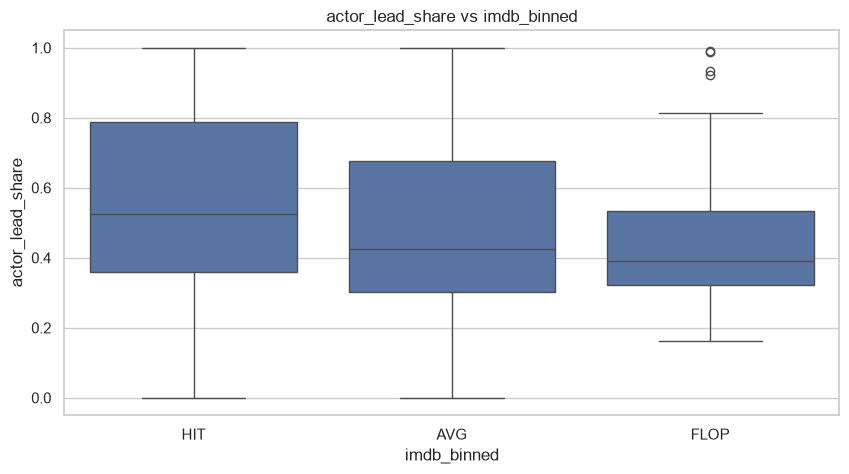

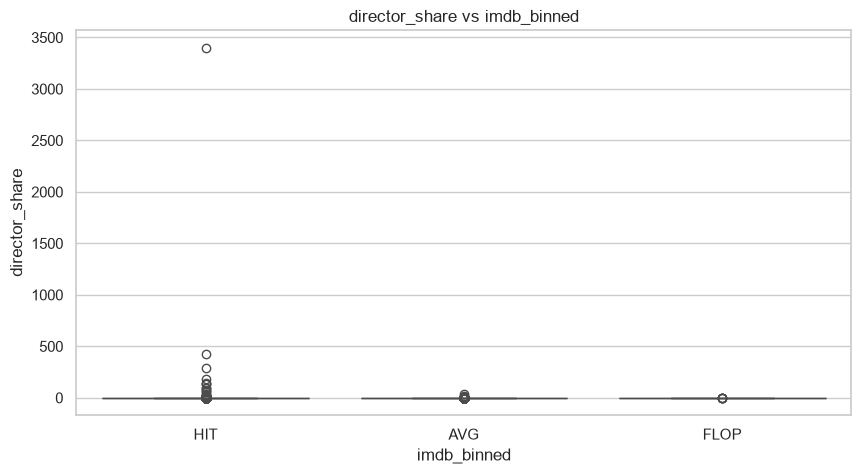

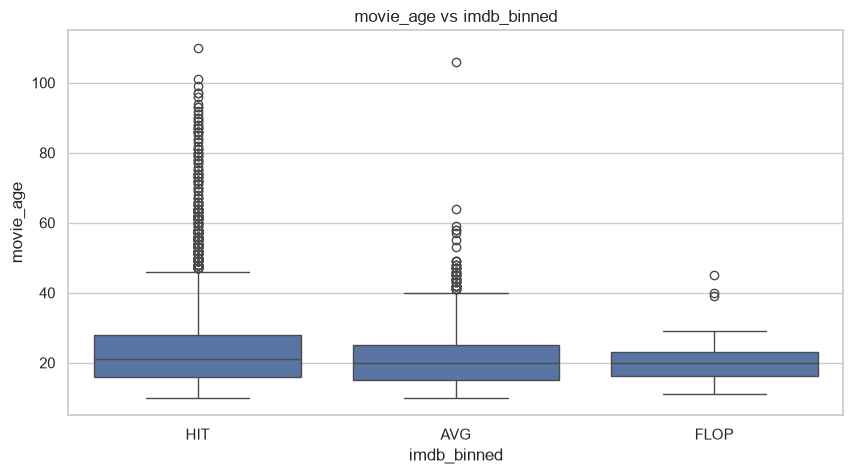

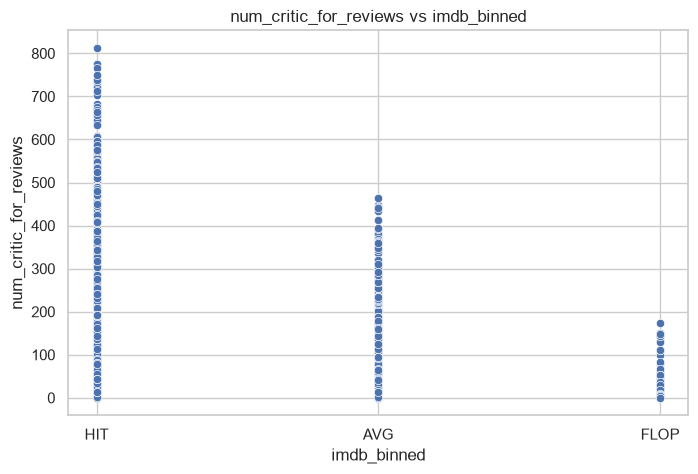

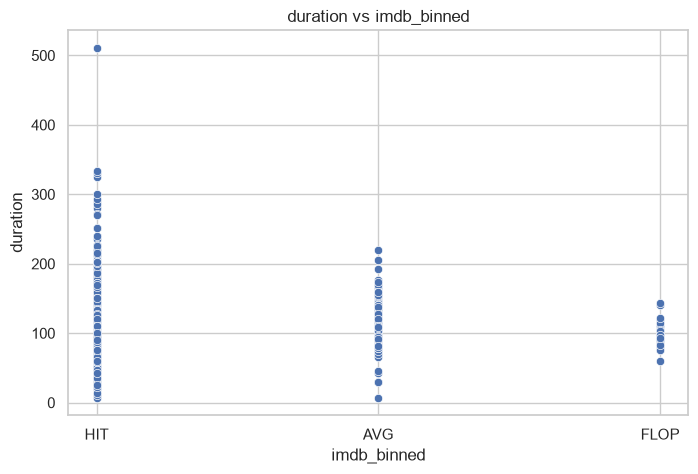

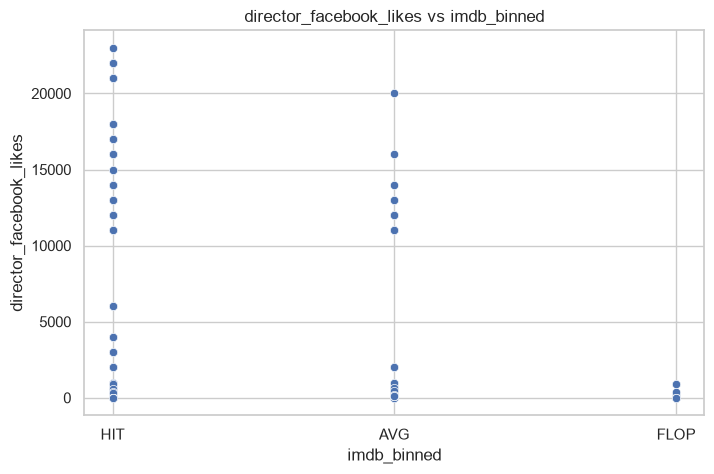

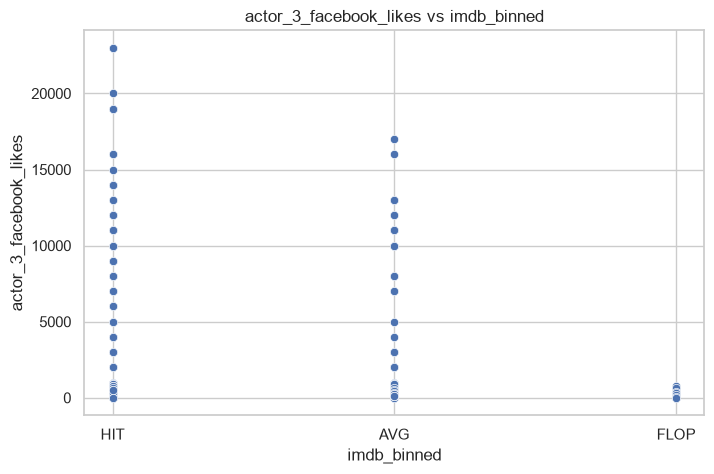

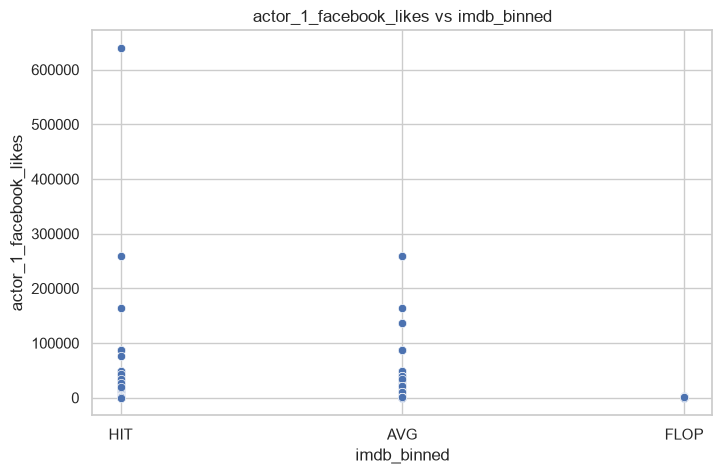

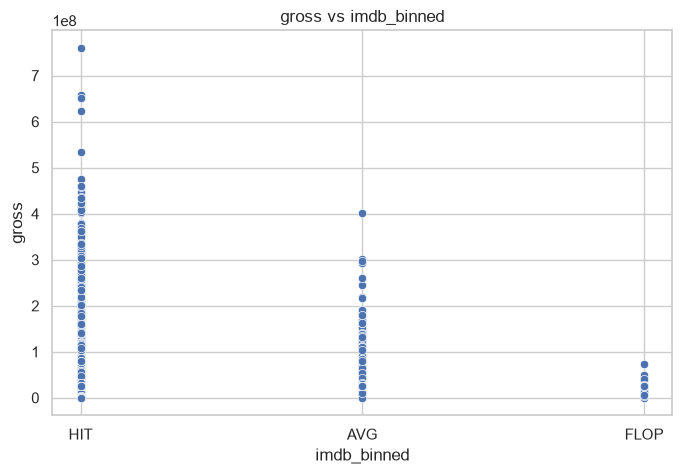

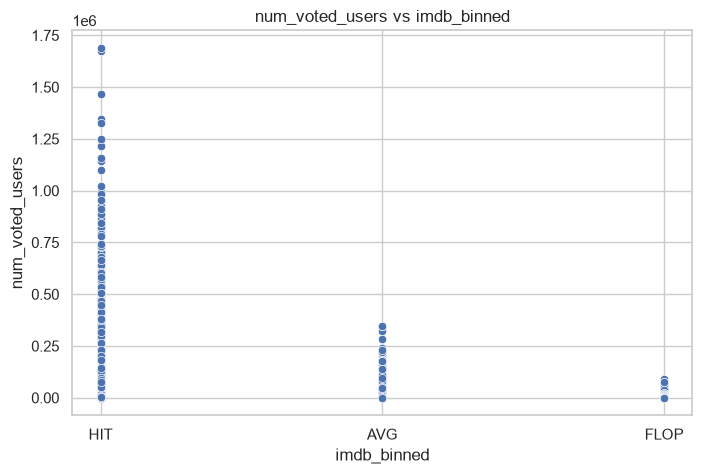

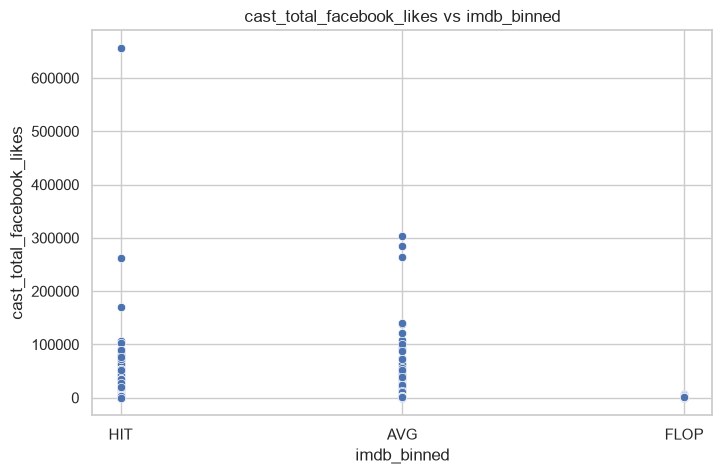

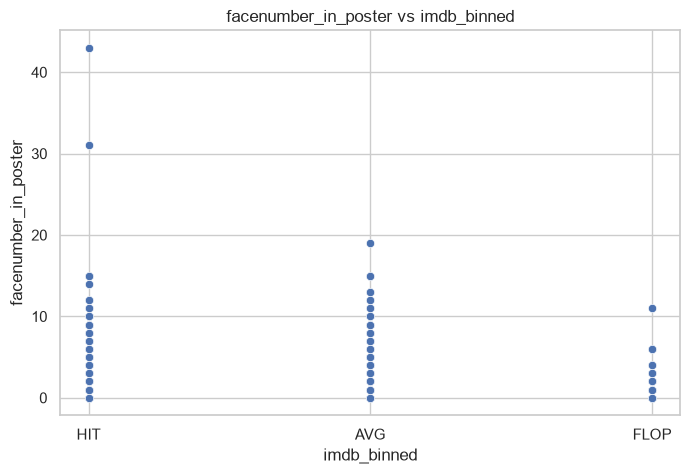

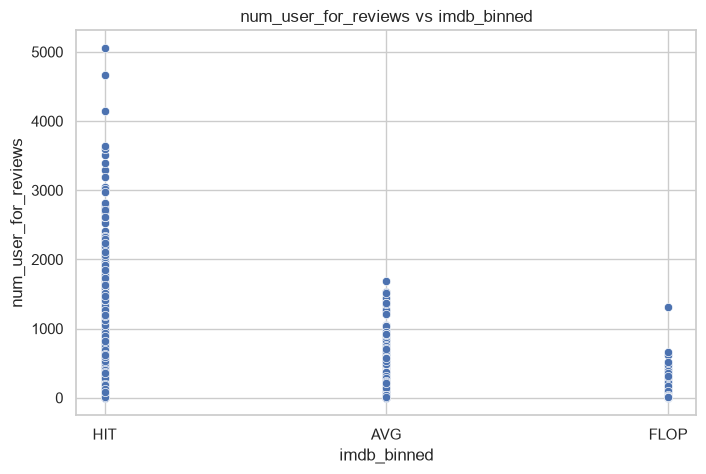

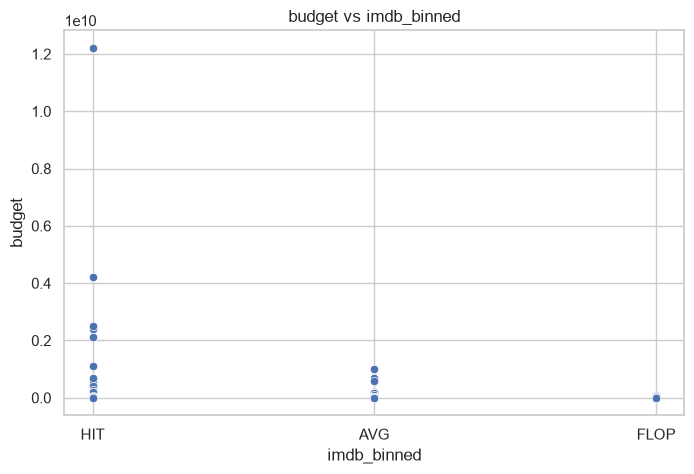

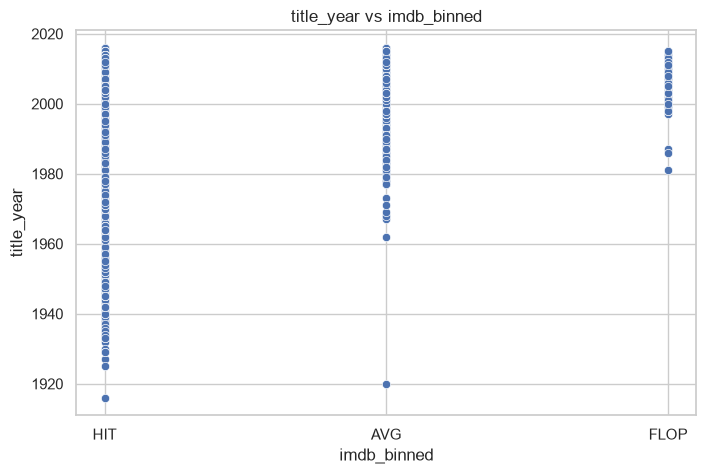

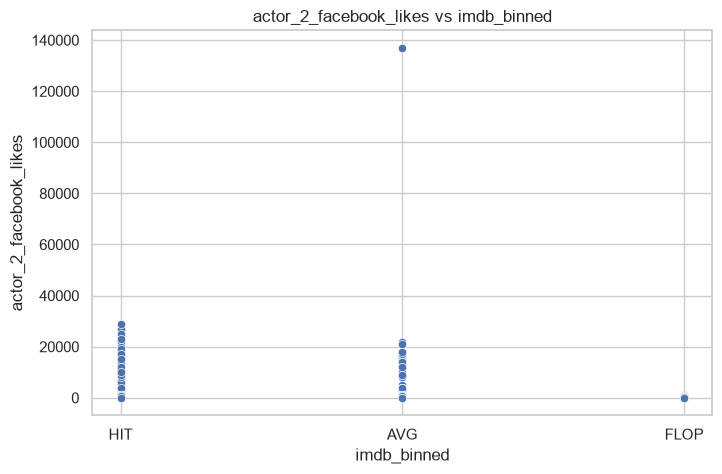

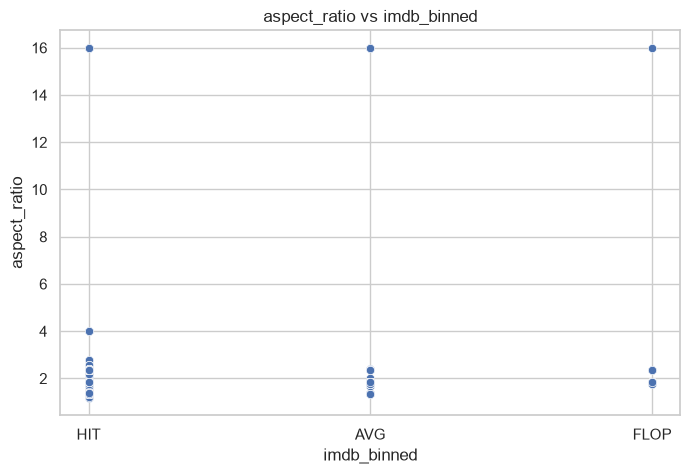

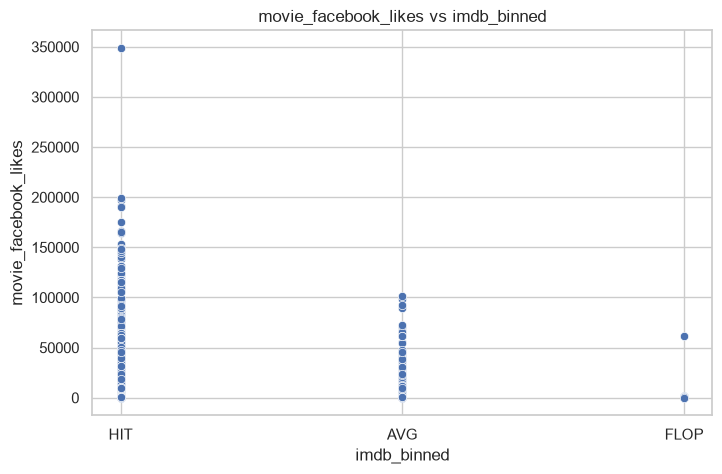

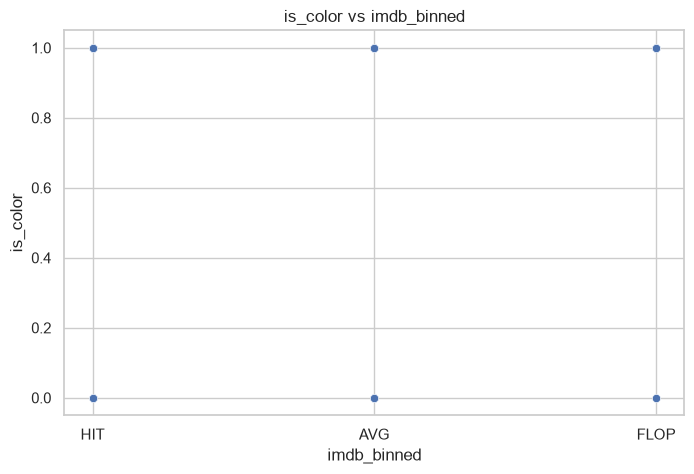

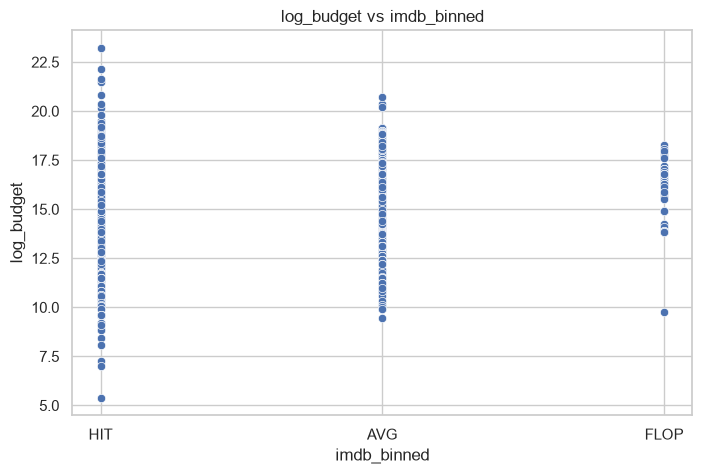

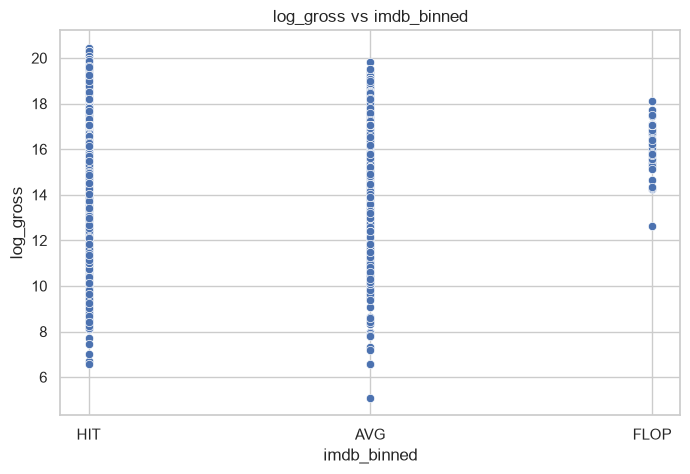

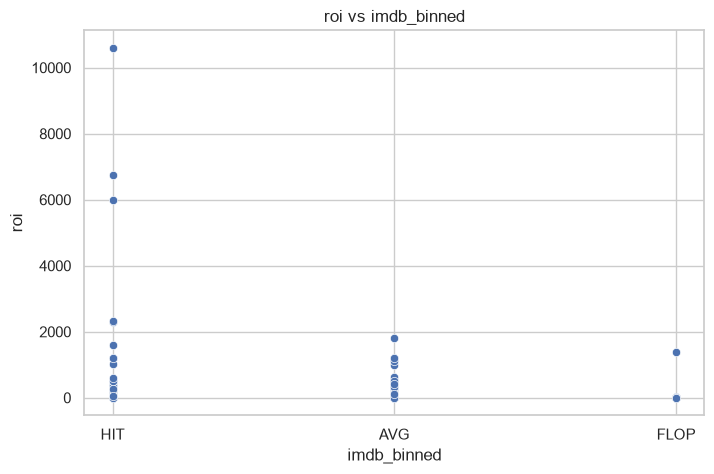

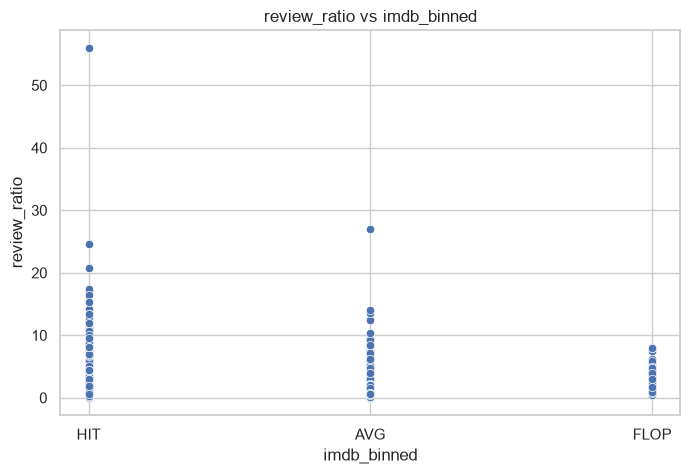

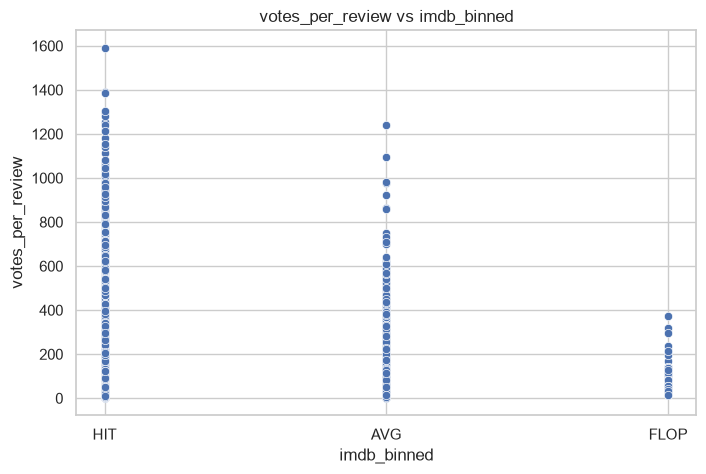

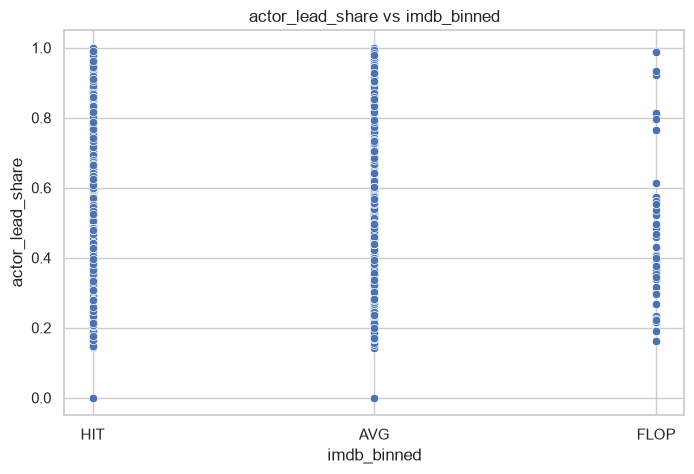

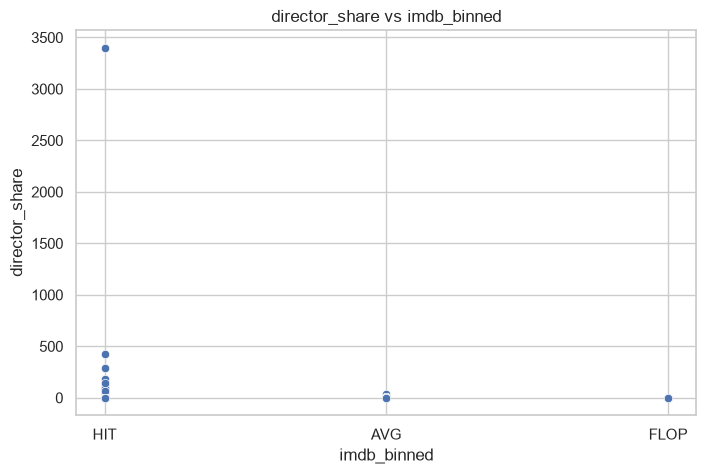

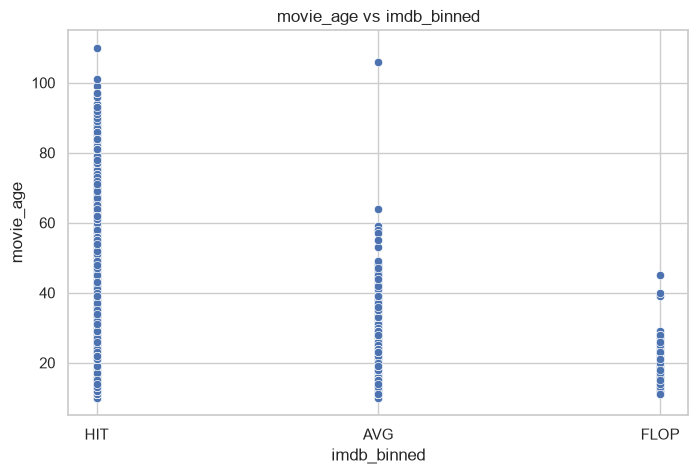

In [14]:
# Numerical Data Analysis
for column in num_cols:

    plot_box(df, column)

for column in num_cols:

    plot_scatter(df, column)

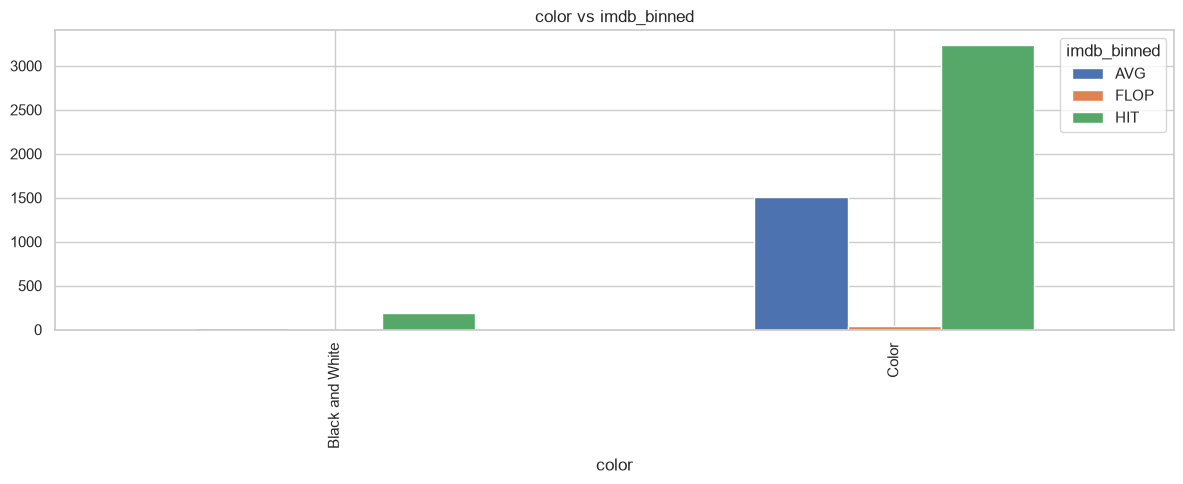

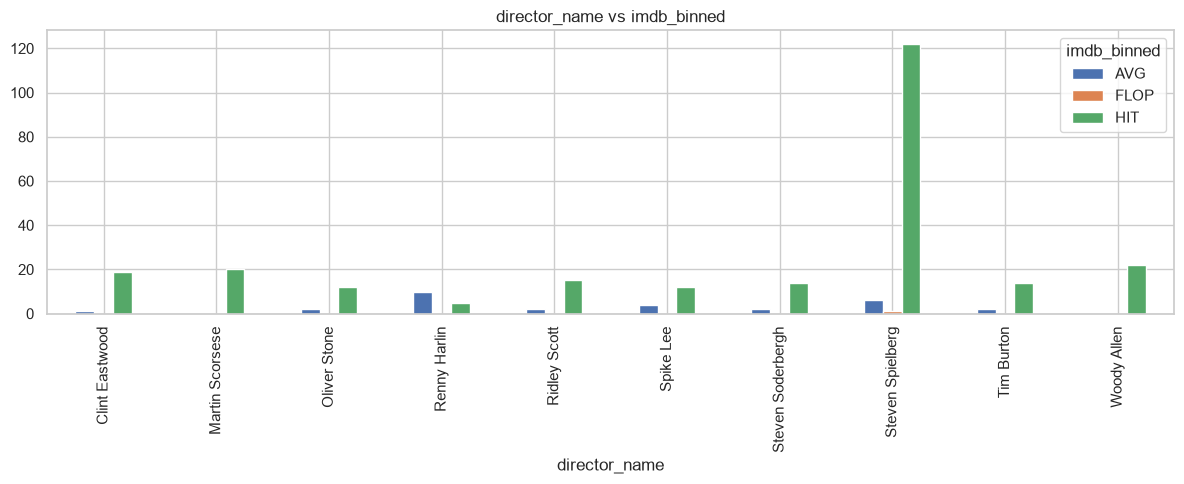

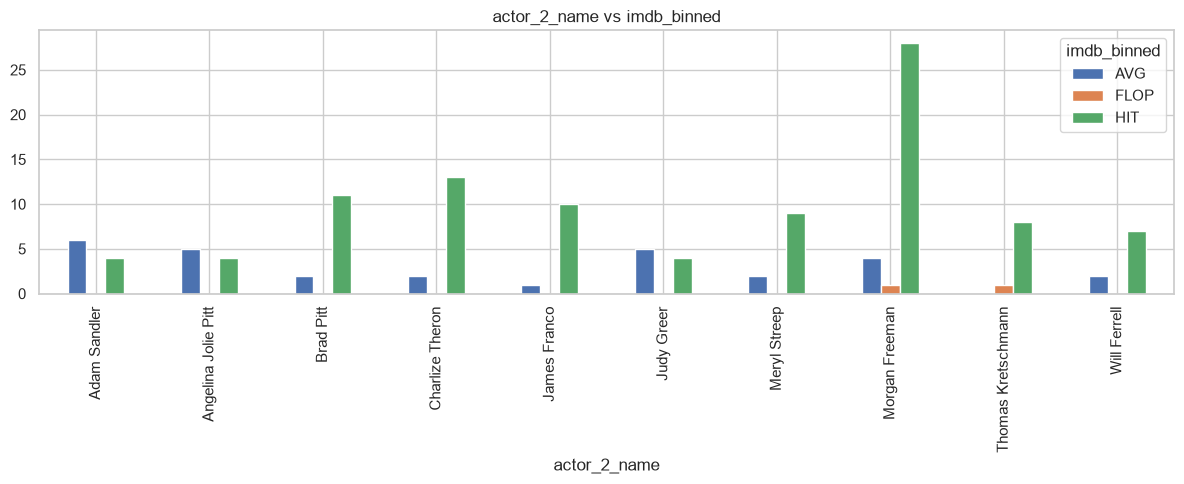

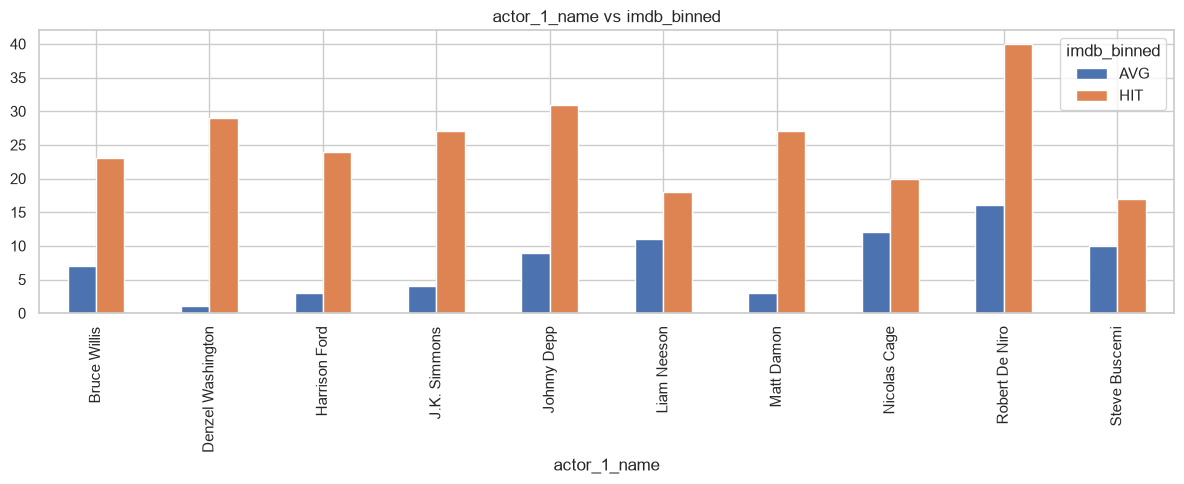

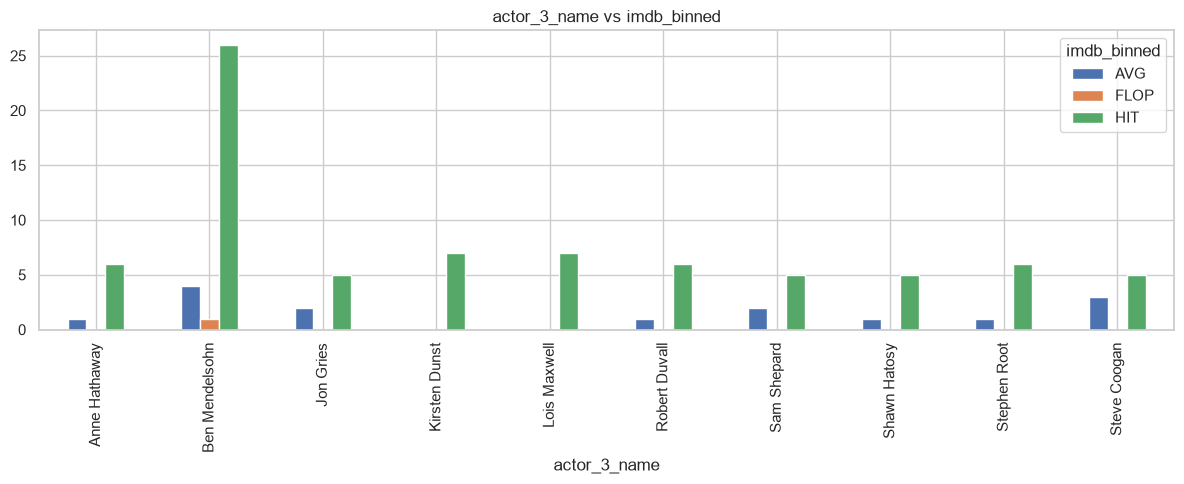

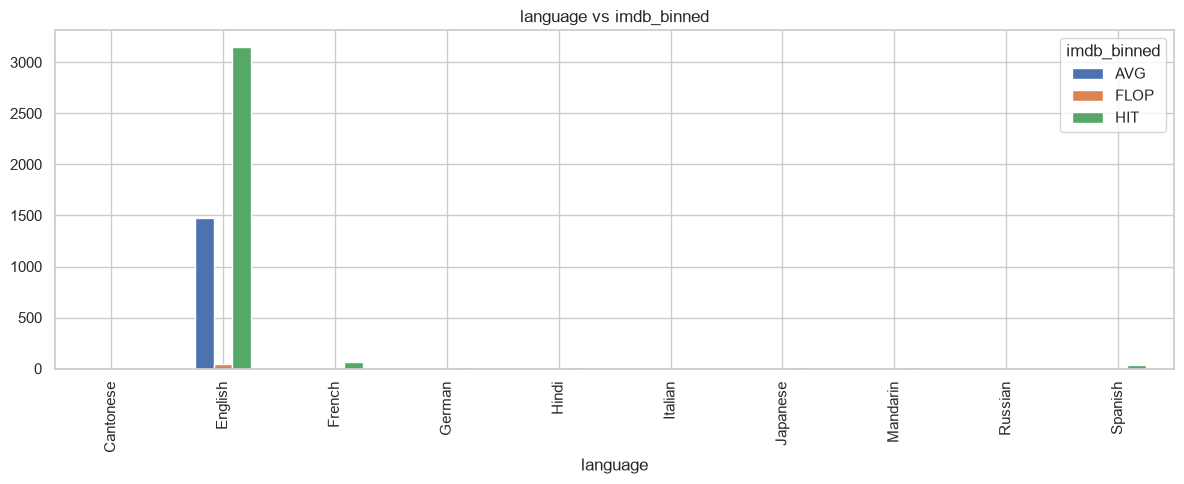

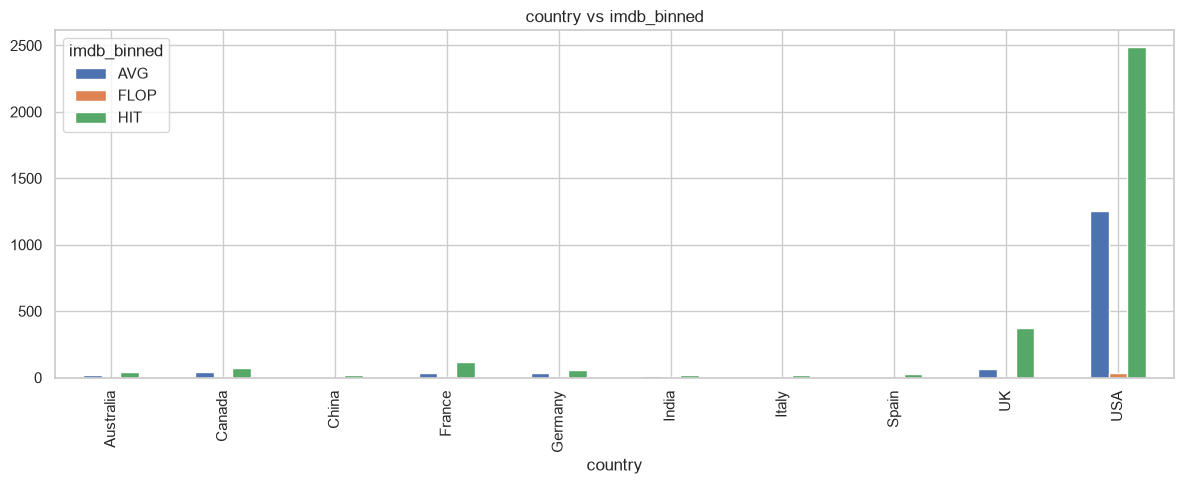

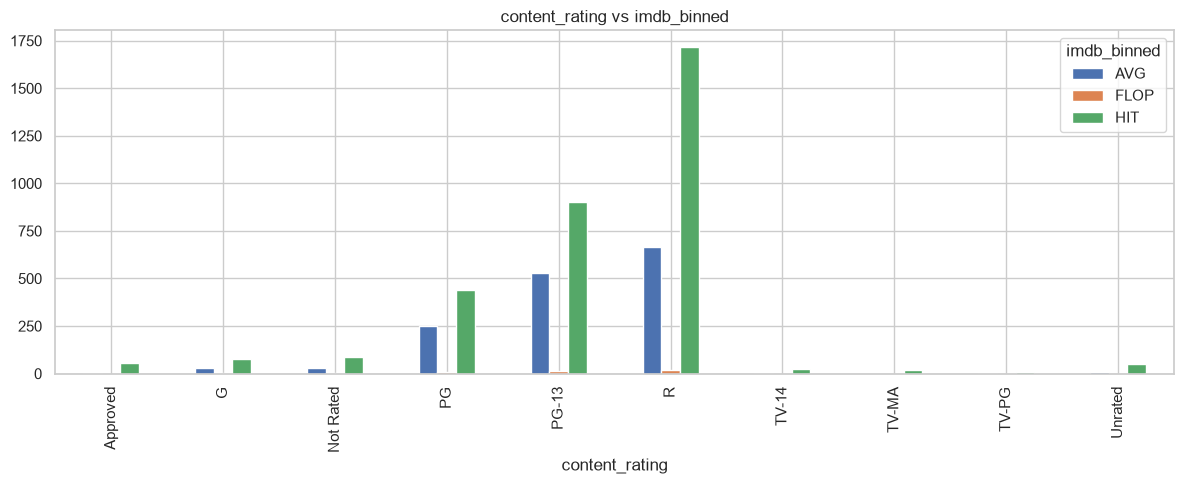

In [15]:
# Categorical data Analysis

ignored = [
    TARGET,
    "genres",
    "plot_keywords"

]
for column in cat_cols:
    if column not in ignored:
        plot_categorical(
            df,
            column
        )

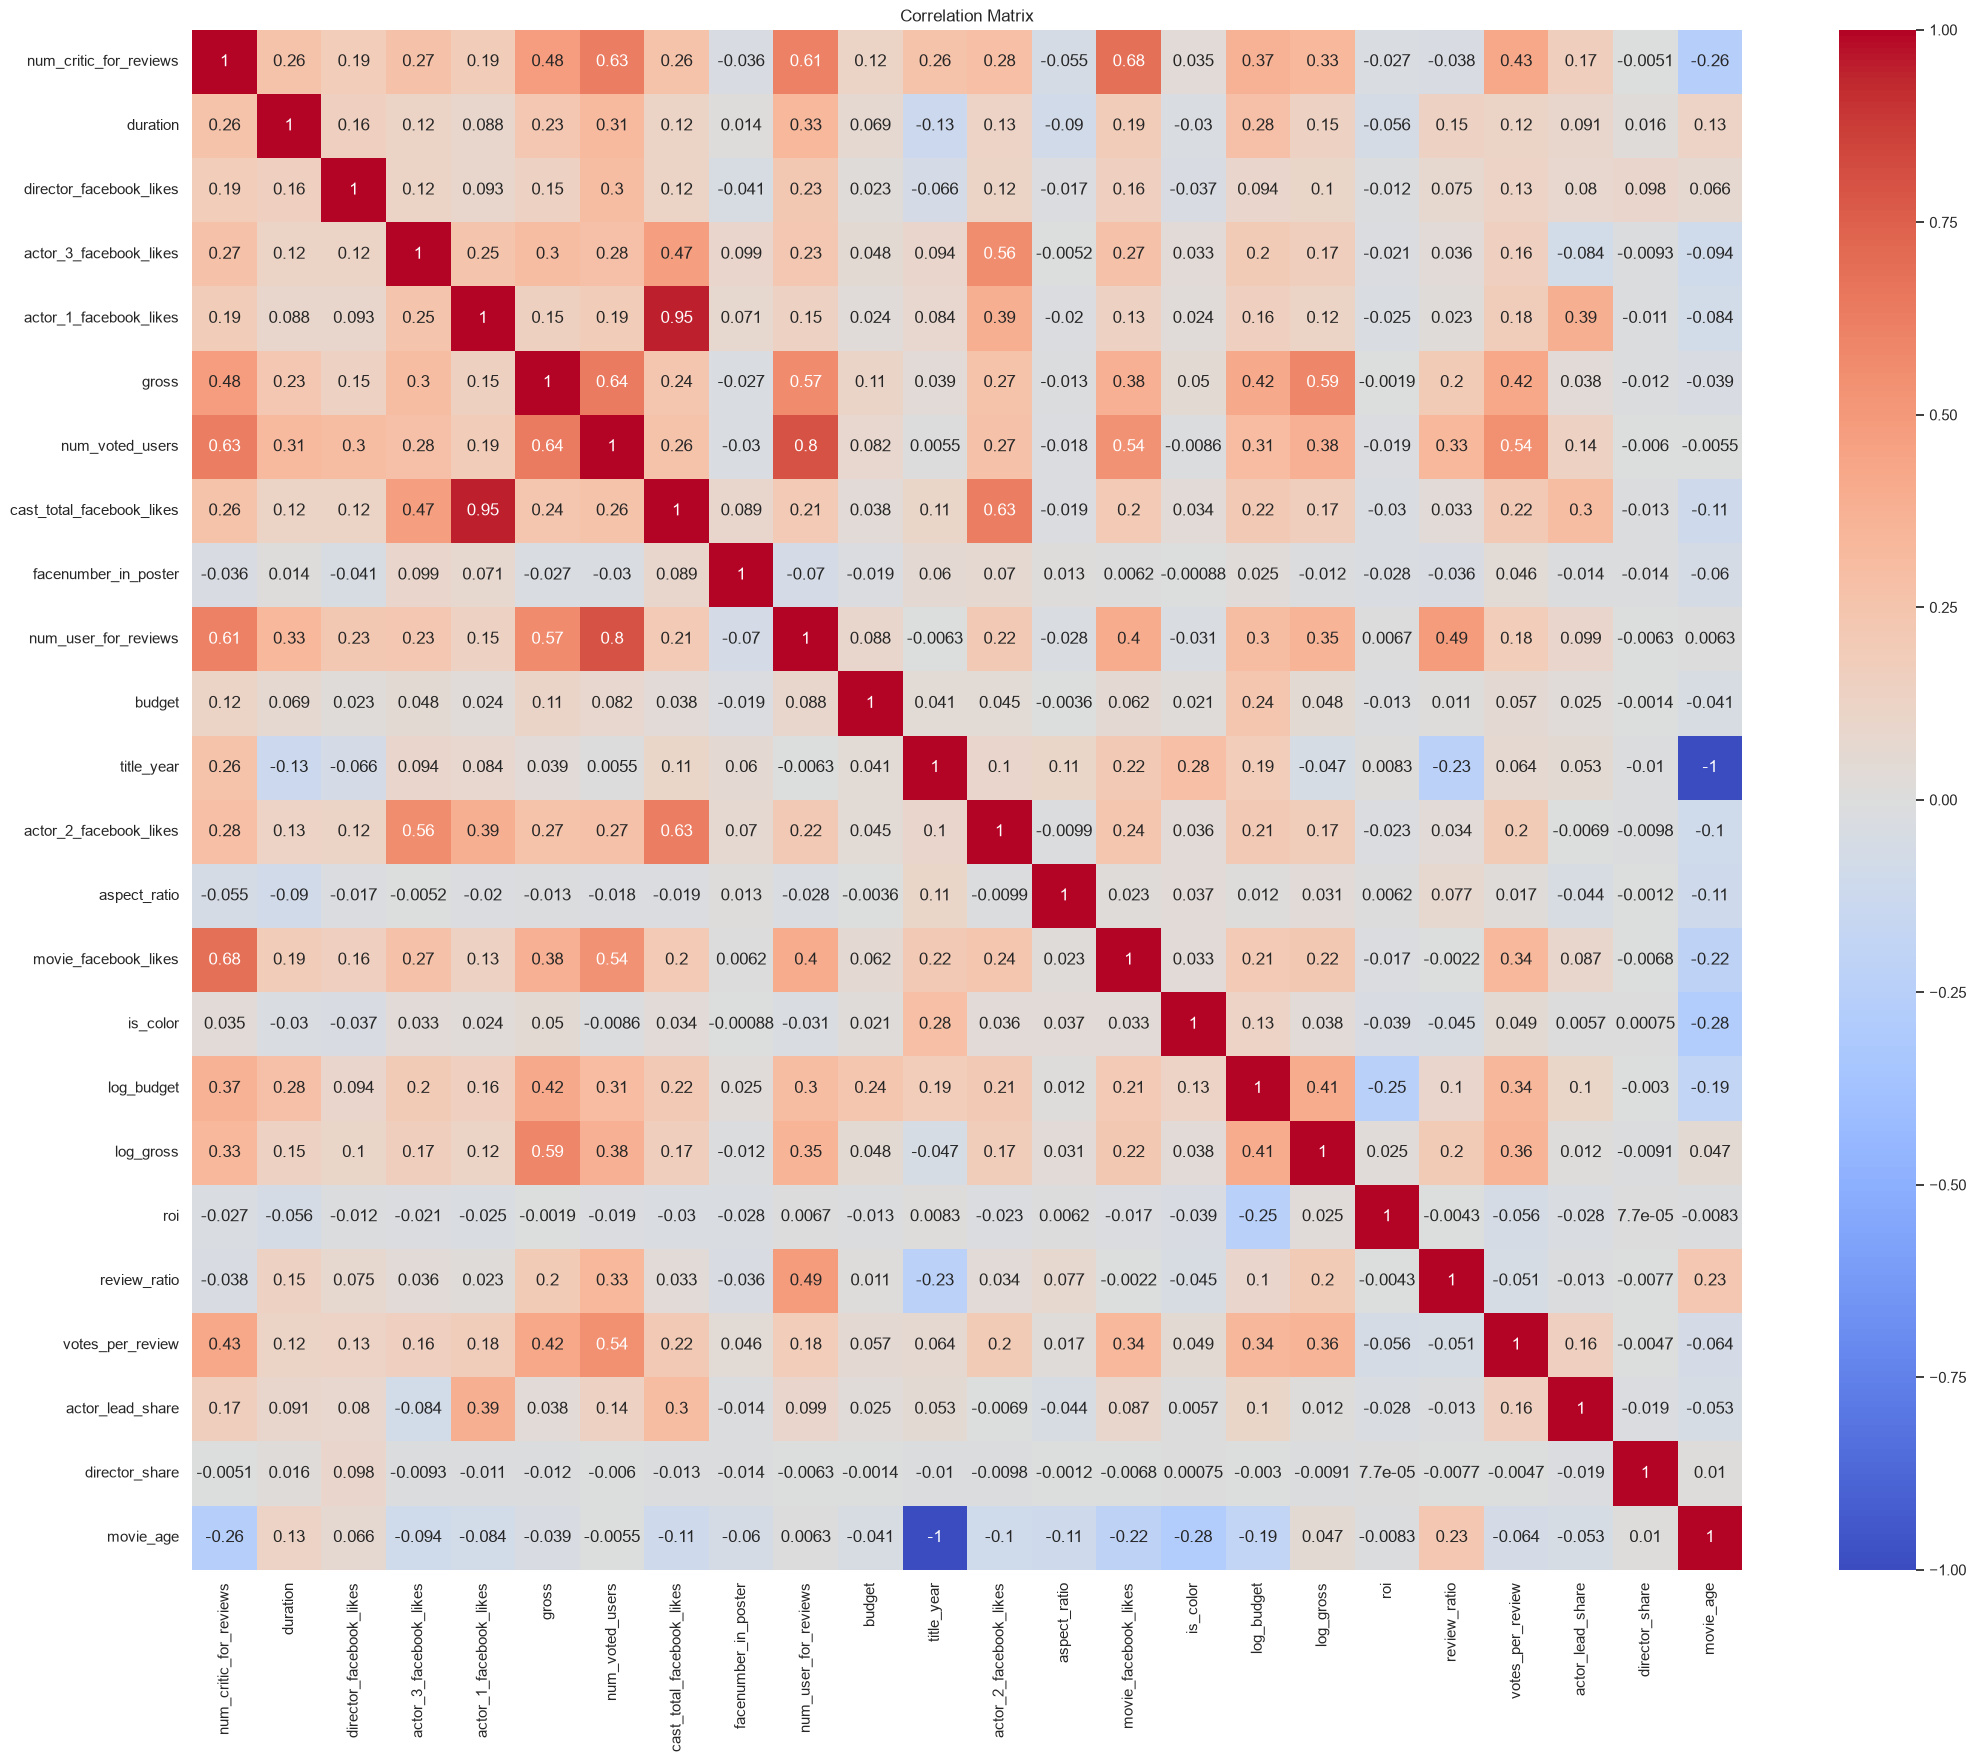

In [18]:
# Correlation Analysis
plt.figure(figsize=(25,20))

sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()